In [94]:
"""
Kigali-style parametric didgeridoo shape generator.

This module implements a sophisticated bore geometry model that combines 
traditional pipe-like characteristics with modern acoustic flares. The 
geometry is generated in a layered approach:

1. **The Genetic Foundation**: Scales genome values (0-1) to physical 
   dimensions including length, bell size, and taper power.
2. **Structural Base**: Can alternate between a pure power-law taper 
   and a hybrid **Cylinder-Cone** transition for traditional yidaki shapes.
3. **Mouthpiece Leadpipe**: Implements a smooth, sigmoid-based taper 
   to control backpressure and playability.
4. **The Jitter Layer**: Adds organic "noise" via segment offsets to 
   mimic natural wood variations and complex overtones.
5. **Acoustic Features**: Adds localized "bubbles" (sinusoidal bulges) 
   and final bell flares to tune specific resonances.
6. **Constraint Layer (RBF)**: Uses Radial Basis Function interpolation 
   to force exact diameters at specific points while maintaining 
   mathematical smoothness.
"""

import numpy as np
from typing import Any, List, Tuple, Optional

from didgelab import Geo, GeoGenome

from scipy.interpolate import Rbf # Ensure scipy is available


class KigaliShape(GeoGenome):
    """
    Parametric bore shape: supports power-law taper, hybrid cylinder-cone 
    transitions, mouthpiece leadpipe tapers, and optional bubbles.

    Genome layout:
    - [0]: length (min_length .. max_length)
    - [1]: bell diameter (d_bell_min .. d_bell_max)
    - [2]: power exponent for taper curve
    - [3 + 3*k : 3 + 3*(k+1)]: per bubble k: position, width, height
    - [geo_offset + 2*j]: x/y jitter offsets for segment j
    - [cyl_offset]: (Optional) transition position for cylinder-cone
    - [cyl_offset + 1]: (Optional) transition diameter for cylinder-cone
    """
    def __init__(
        self,
        n_segments: int = 24,
        d0: float = 32,
        d_bell_min: float = 50,
        d_bell_max: float = 80,
        max_length: float = 1900,
        min_length: float = 1500,
        n_bubbles: int = 0,
        smoothness: float = 0.3,
        bell_accent: float = 0.0,
        bell_start: float = 300,
        n_bell_segments: int = 10,
        forced_diameters: Optional[List[Tuple[float, float, float]]] = None,        
        sine_shape_n : float = 0.0,
        sine_shape_y : float = 0.0,
        enable_cylinder_cone : bool = False,
        cylinder_cone_z_pos : List[float] = [0.3, 0.7],
        cylinder_cone_transition_diameter : List[float] = [32, 36],
        enable_taper : bool = False,
        taper_start: float = 20,
        taper_end: float = 50,
        taper_diameter: float = 20,
        taper_n_segments: int = 8,
    ):
        """
        Args:
            n_segments: Number of bore segments (excluding endpoints) for the base taper.
            d0: Mouthpiece (input) diameter in mm.
            d_bell_min: Minimum bell diameter in mm (genome maps [0,1] to [d_bell_min, d_bell_max]).
            d_bell_max: Maximum bell diameter in mm.
            max_length: Maximum bore length in mm.
            min_length: Minimum bore length in mm.
            n_bubbles: Number of optional bulge (bubble) features along the bore.
            smoothness: Fraction of bell size used to scale segment y-offsets (0..1).
            bell_accent: If > 0, the last bell_start mm of the bore is accentuated by this factor.
            bell_start: Length (mm) from the bell end over which the bell accent is applied.
            n_bell_segments: Number of points used to build the accentuated bell curve.
            forced_diameters: A list of triples [(pos_pct, diam, length), ...] defining 
                geometric constraints along the bore:
                - pos_pct (float): The longitudinal position expressed as a percentage of 
                the total bore length (0 = mouthpiece, 1 = bell end).
                - diam (float): The target internal diameter in mm to be enforced 
                at that position.
                - length (float): The longitudinal distance (mm) over which this diameter 
                should be maintained. If > 0, the code creates a cylindrical section 
                centered at the calculated position.            
            taper_start: Distance (mm) where the mouthpiece restriction begins.
            taper_end: Distance (mm) where the bore returns to its natural diameter.
            taper_diameter: The target internal diameter (mm) of the mouthpiece bottleneck.
            enable_cylinder_cone: If True, replaces power-law with a cylindrical-to-conical transition.
            cylinder_cone_z_pos: Min/Max relative range [0, 1] for the transition point.
            cylinder_cone_transition_diameter: Min/Max range (mm) for the diameter at the transition.
        """

        self.max_length = max_length
        self.min_length = min_length
        self.n_segments = n_segments
        self.d0 = d0
        self.d_bell_min = d_bell_min
        self.d_bell_max = d_bell_max
        self.n_bubbles = n_bubbles
        self.smoothness = smoothness
        self.bell_accent = bell_accent
        self.bell_start = bell_start
        self.n_bell_segments = n_bell_segments
        self.forced_constraints = forced_diameters if (forced_diameters is not None and len(forced_diameters) > 0) else []
        self.sine_shape_n : float = sine_shape_n
        self.sine_shape_y : float = sine_shape_y

        self.bubble_width = 300
        self.bubble_height = 40
        self.geo_offset = 3 + self.n_bubbles * 3
        genome_length = self.geo_offset + 2 * (n_segments - 1)

        self.n_bubble_segments = 10

        self.enable_cylinder_cone = enable_cylinder_cone
        self.cylinder_cone_z_pos = cylinder_cone_z_pos
        self.cylinder_cone_transition_diameter = cylinder_cone_transition_diameter

        if self.enable_cylinder_cone:
            self.cyliner_cone_genome_offset = genome_length
            genome_length += 2

        self.enable_taper = enable_taper
        self.taper_start = taper_start
        self.taper_end = taper_end
        self.taper_diameter = taper_diameter
        self.taper_n_segments = taper_n_segments
        
        GeoGenome.__init__(self, n_genes=genome_length)

    def get_properties(self) -> Tuple[float, float, float, np.ndarray, np.ndarray, List]:
        """
        Decode genome into length, bell size, power, segment offsets, and bubble list.

        Returns:
            Tuple of (length_mm, bell_size_mm, power, x_genome, y_genome, bubbles).
            bubbles is a list of (pos, width, height) per bubble.
        """
        length = self.genome[0] * (self.max_length - self.min_length) + self.min_length
        bell_size = self.genome[1] * (self.d_bell_max - self.d_bell_min) + self.d_bell_min
        power = self.genome[2] * 4

        bubbles = []
        j = 3
        for i in range(self.n_bubbles):
            pos = self.bubble_width + self.genome[j] * (length - 2 * self.bubble_width)
            width = self.bubble_width * (0.2 + self.genome[j + 1]) / 1.2
            height = (0.2 + self.genome[j + 2]) * self.bubble_height / 1.2
            j += 3
            bubbles.append((pos, width, height))

        # FIX: Define exactly where the jitter genes end so we don't 
        # accidentally include the cylinder/cone genes in the x/y jitter arrays.
        jitter_end = self.geo_offset + 2 * (self.n_segments - 1)
        
        jitter_genes = self.genome[self.geo_offset : jitter_end]
        x_genome = jitter_genes[0::2] # Every even index
        y_genome = jitter_genes[1::2] # Every odd index

        return length, bell_size, power, x_genome, y_genome, bubbles
        
    def apply_mouthpiece_taper(self, x: np.ndarray, y: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """
        Creates a restricted 'bottleneck' effect:
        - d0 until taper_start
        - Smooth transition to taper_diameter
        - Smooth transition back to main bore by taper_end
        """
        # Define the key transition points within the taper zone
        # We'll split the space between start and end into thirds for the sigmoids
        zone_width = (self.taper_end - self.taper_start) / 3
        p1 = self.taper_start + zone_width # End of first sigmoid
        p2 = self.taper_start + 2 * zone_width # Start of second sigmoid

        # 1. Fixed Entry (0 to taper_start)
        x_0 = np.linspace(0, self.taper_start, 5)
        y_0 = np.full_like(x_0, self.d0)

        # 2. Inbound Sigmoid (taper_start to p1)
        x_1 = np.linspace(self.taper_start, p1, self.taper_n_segments)
        s1 = 1 / (1 + np.exp(-np.linspace(5, -5, self.taper_n_segments))) # Inverted sigmoid
        y_1 = self.taper_diameter + (self.d0 - self.taper_diameter) * s1

        # 3. The Bottleneck (p1 to p2)
        x_2 = np.linspace(p1, p2, 5)
        y_2 = np.full_like(x_2, self.taper_diameter)

        # 4. Outbound Sigmoid (p2 to taper_end)
        x_3 = np.linspace(p2, self.taper_end, self.n_segments // 2)
        temp_geo = Geo(list(zip(x, y)))
        target_d = Geo.diameter_at_x(temp_geo, self.taper_end)
        s2 = 1 / (1 + np.exp(-np.linspace(-5, 5, len(x_3))))
        y_3 = self.taper_diameter + (target_d - self.taper_diameter) * s2

        # 5. Combine and Clean
        mask_after = x > self.taper_end
        x_new = np.concatenate((x_0, x_1, x_2, x_3, x[mask_after]))
        y_new = np.concatenate((y_0, y_1, y_2, y_3, y[mask_after]))
        
        # Unique/Sorted to prevent Geo errors
        _, indices = np.unique(x_new, return_index=True)
        return x_new[indices], y_new[indices]


    def force_diameters(self, x, y, length):
        if len(self.forced_constraints) > 0:
            # We will use RBF to find the 'deformation' required to hit targets
            target_pts = []
            target_diams = []
            
            for pos_pct, diam, f_length in self.forced_constraints:
                center_x = pos_pct * length
                
                if f_length > 0:
                    # To ensure it's a perfect cylinder, we sample multiple points 
                    # along the forced length to "overpower" any local jitter.
                    half_len = f_length / 2
                    side_pts = np.linspace(center_x - half_len, center_x + half_len, 5)
                    for p in side_pts:
                        target_pts.append(p)
                        target_diams.append(diam)
                else:
                    target_pts.append(center_x)
                    target_diams.append(diam)

            # Create a temporary geometry to see how far off the current "genetic" bore is
            temp_geo = Geo(list(zip(x, y)))
            f_x = np.array(target_pts)
            f_d_target = np.array(target_diams)
            
            # Calculate the difference (delta) between target and current evolved shape
            f_d_current = np.array([Geo.diameter_at_x(temp_geo, xi) for xi in f_x])
            deltas = f_d_target - f_d_current
            
            # Anchor mouthpiece and bell (0 delta) so they remain at genetic values
            all_f_x = np.concatenate([[0], f_x, [length]])
            all_deltas = np.concatenate([[0], deltas, [0]])
            
            # RBF Interpolation with 'thin_plate' creates a smooth 'warp' function
            # that hits your deltas exactly at the specified points.
            itp = Rbf(all_f_x, all_deltas, function='thin_plate')
            
            # Apply the warp to the diameter array
            y += itp(x)

        return x,y

    def create_cylinder_cone_y(self, bell_size: float) -> np.ndarray:
        """
        Generates a diameter profile that starts cylindrical (up to a genome-defined point)
        and then opens conically to the bell size.
        """
        # Linear spacing of segments from 0 to 1
        z_relative = np.linspace(0, 1, self.n_segments + 1)
        
        # Extract genome values for the transition
        g_pos = self.genome[self.cyliner_cone_genome_offset]
        g_diam = self.genome[self.cyliner_cone_genome_offset + 1]

        # Map genome to real-world transition values
        # transition_z: relative position [0..1] along the length
        z_min, z_max = self.cylinder_cone_z_pos
        transition_z = g_pos * (z_max - z_min) + z_min
        
        # transition_d: diameter at the end of the cylindrical section
        d_min, d_max = self.cylinder_cone_transition_diameter
        transition_d = g_diam * (d_max - d_min) + d_min

        y = np.zeros_like(z_relative)

        for i, z in enumerate(z_relative):
            if z <= transition_z:
                # Cylindrical/Linear transition from mouthpiece to transition_d
                # (Allows it to be non-strictly cylindrical if d0 != transition_d)
                y[i] = self.d0 + (z / transition_z) * (transition_d - self.d0)
            else:
                # Conical flare from the transition point to the bell
                # Calculate progress from transition point to the end (1.0)
                flare_progress = (z - transition_z) / (1.0 - transition_z)
                y[i] = transition_d + flare_progress * (bell_size - transition_d)
        
        return y


    def genome2geo(self) -> Geo:
        length, bell_size, power, x_genome, y_genome, bubbles = self.get_properties()

        # 1. Generate Base Geometry (Power-law taper)
        x = np.linspace(0, length, self.n_segments + 1)

        if self.enable_cylinder_cone:
            y = self.create_cylinder_cone_y(bell_size)
        else:
            y = np.power(np.linspace(0, 1, self.n_segments + 1), power)
            # Linear scale from mouthpiece to bell_size
            y = y * (bell_size - self.d0) + self.d0

        # Apply genome jitter/offsets
        shift_x = length / self.n_segments
        x += np.concatenate(([0], (x_genome - 0.5) * shift_x, [0]))
        shift_y = (1 - self.smoothness) * bell_size
        y += np.concatenate(([0], 0.3 * (y_genome - 0.5) * shift_y, [0]))

        # 2. Apply the Mouthpiece Taper
        if self.enable_taper:
            x, y = self.apply_mouthpiece_taper(x, y)

        # 2. Apply Bell Accent
        x, y = self.apply_bell_accent(x, y, length, bell_size)

        # 3. Add Bubbles
        for bubble in bubbles:
            # Unpack the tuple: (position, width, height)
            pos, width, height = bubble
            x, y = self.make_bubble(x, y, pos, width, height)

        x, y = self.add_sine_shape(x, y)
        
        # 4. Force Exact Diameters (RBF)
        x, y = self.force_diameters(x, y, length)

        # 5. Finalize (Clamp to ensure d_bell_max is respected)
        # We clamp to bell_size specifically here
        x, y = self.fix_didge(x, y, self.d0, bell_size)
        
        return Geo(list(zip(x, y)))

    def fix_didge(
        self, x: np.ndarray, y: np.ndarray, d0: float, bellsize: float
    ) -> Tuple[np.ndarray, np.ndarray]:
        """
        Clamp bore diameter to [0.9*d0, 1.3*bellsize] to avoid invalid geometry.

        Args:
            x: Array of x positions along the bore (mm).
            y: Array of bore diameters at each x (mm).
            d0: Mouthpiece diameter in mm; minimum allowed is 0.9*d0.
            bellsize: Bell diameter in mm; maximum allowed is 1.3*bellsize.

        Returns:
            Tuple (x, y) of arrays with y clamped; x unchanged.
        """
        mind = d0 * 0.5
        x, y = x.copy(), y.copy()
        y[y < mind] = mind
        y[y > bellsize * 1.3] = bellsize * 1.3
        return x, y

    def make_bubble(
        self,
        x: np.ndarray,
        y: np.ndarray,
        pos: float,
        width: float,
        height: float,
    ) -> Tuple[np.ndarray, np.ndarray]:
        """
        Insert a sinusoidal bulge (bubble) at pos with given width and height.

        The bubble is clamped so it does not extend past the bore ends. Bore diameter
        inside the bubble is existing diameter plus a half-sine bulge of given height.

        Args:
            x: Array of x positions along the bore (mm).
            y: Array of bore diameters at each x (mm).
            pos: Center x position of the bubble (mm).
            width: Length of the bubble along the bore (mm).
            height: Amplitude of the bulge in mm (added to local bore diameter).

        Returns:
            Tuple (x_new, y_new) of arrays with the segment in [pos-width/2, pos+width/2]
            replaced by bubble points.
        """
        bubble_start_x = pos - 0.5 * width
        bubble_end_x = pos + 0.5 * width

        if bubble_start_x < 20:
            diff = 20-bubble_start_x
            bubble_start_x += diff
            bubble_end_x += diff

        if bubble_end_x > x[-1]:
            diff = bubble_end_x-x[-1]
            bubble_start_x -= diff
            bubble_end_x -= diff

        bubble_x = np.linspace(
            bubble_start_x, bubble_end_x, self.n_bubble_segments, endpoint=False
        )

        # Bore diameter at bubble x, plus half-sine bulge
        geo = Geo(list(zip(x, y)))
        bubble_y_1 = np.array([Geo.diameter_at_x(geo, xi) for xi in bubble_x])
        bubble_y_2 = height * np.sin(
            np.pi * np.arange(self.n_bubble_segments) / self.n_bubble_segments
        )
        bubble_y = bubble_y_1 + bubble_y_2

        # Replace segment inside [bubble_start_x, bubble_end_x] with bubble points
        y = np.concatenate((y[x < bubble_start_x], bubble_y, y[x > bubble_end_x]))
        x = np.concatenate((x[x < bubble_start_x], bubble_x, x[x > bubble_end_x]))
        return x, y

    def apply_bell_accent(self, x: np.ndarray, y: np.ndarray, length: float, bell_size: float) -> np.ndarray:
        """
        Applies a flare to the end of the didgeridoo. 
        If bell_accent is 0, it follows the existing taper.
        If bell_accent is 1, it adds a sharp parabolic flare.
        """
        if self.bell_accent <= 0:
            return x, y

        if self.bell_accent > 1:
            self.bell_accent = 1

        # insert a segment at bell_start position
        bell_start = x[-1] - self.bell_start
        if bell_start < 1:
            bell_start = 1

        if bell_start not in x:
            segments = list(zip(x,y))
            geo = Geo(segments)
            bell_start_diameter = Geo.diameter_at_x(geo, bell_start)
            segments.append([bell_start, bell_start_diameter])
            segments = sorted(segments, key=lambda x:x[0])
            segments = np.array(segments)
            x = segments[:,0]
            y = segments[:,1]

        bell_size_before = y[-1]

        y = (1-0.7*self.bell_accent)*(y-self.d0)
        y += self.d0

        segments = list(zip(x,y))
        geo = Geo(segments)

        x_bell = np.linspace(bell_start, length, self.n_bell_segments)
        y_bell = [Geo.diameter_at_x(geo, _x) for _x in x_bell]

        x_sigmoid = np.linspace(-5, 5., self.n_bell_segments)
        delta = (bell_size_before-y[-1]) * (1-(1/(1 + np.exp(x_sigmoid)))) # sigmoid function
        y_bell += delta

        i1 = x<bell_start

        x = np.concatenate((x[i1], x_bell))
        y = np.concatenate((y[i1], y_bell))

        return x, y

    def add_sine_shape(self, x, y):

        if self.sine_shape_n <= 0 or self.sine_shape_y <= 0:
            return x, y

        x_sine = 2*self.sine_shape_n*np.pi*x/x.max()
        y_sine = np.sin(x_sine)
        y_sine[y_sine<0] = 0

        y += self.sine_shape_y * y_sine
        return x,y



[(0.0, 32.0),
 (2.5, 32.0),
 (5.0, 32.0),
 (7.5, 32.0),
 (10.0, 32.0),
 (11.904761904761905, 31.671838558445806),
 (13.80952380952381, 30.73999297975682),
 (15.714285714285715, 28.05616944179276),
 (17.61904761904762, 23.94383055820724),
 (19.523809523809526, 21.260007020243176),
 (21.42857142857143, 20.328161441554194),
 (23.333333333333336, 20.08031421109142),
 (26.66666666666667, 20.0),
 (30.000000000000004, 20.0),
 (33.333333333333336, 20.0),
 (36.66666666666667, 20.0),
 (37.36842105263158, 20.13540863452066),
 (38.07017543859649, 20.227427643068918),
 (38.77192982456141, 20.379978218521433),
 (39.47368421052632, 20.62938755577539),
 (40.17543859649123, 21.028030321432677),
 (40.877192982456144, 21.642713929979053),
 (41.578947368421055, 22.539912013014355),
 (42.280701754385966, 23.749854679149628),
 (42.98245614035088, 25.21849453187888),
 (43.684210526315795, 26.789429050256395),
 (44.385964912280706, 28.258068902985645),
 (45.08771929824562, 29.468011569120925),
 (45.7894736842

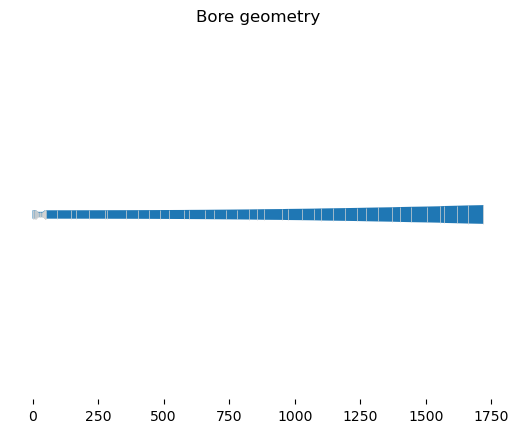

In [93]:

from didgelab import plot_bore

np.random.seed(0)

shape = KigaliShape(
    n_segments=40,
    enable_cylinder_cone=False,
    cylinder_cone_z_pos=[0.5, 0.5],
    cylinder_cone_transition_diameter=[32, 32],
    smoothness=1.0,
    enable_taper = True,
    taper_start=10,
    taper_end = 50,
    taper_diameter=20,
    taper_n_segments=8
)
geo = shape.genome2geo()
plot_bore(geo)
geo.geo

In [76]:
geo.geo

[(0.0, 32.0),
 (2.5, 32.0),
 (5.0, 32.0),
 (7.5, 32.0),
 (10.0, 32.0),
 (14.444444444444445, 32.0),
 (18.88888888888889, 32.0),
 (23.333333333333336, 32.0),
 (27.77777777777778, 32.0),
 (32.22222222222222, 32.0),
 (36.66666666666667, 32.0),
 (41.111111111111114, 32.0),
 (45.55555555555556, 32.0),
 (50.0, 32.0),
 (81.96303114104249, 32.0),
 (144.45144432338273, 32.0),
 (153.18766210196432, 32.0),
 (219.61026794465823, 32.0),
 (267.22951676502754, 32.0),
 (298.2452176039919, 32.0),
 (367.8358208509651, 32.0),
 (389.5779983226034, 32.0),
 (425.02869719667285, 32.0),
 (492.8960501009997, 32.0),
 (539.4010488920605, 32.0),
 (573.2138669226284, 32.0),
 (594.2353451073731, 32.0),
 (640.2517372399388, 32.0),
 (708.596783479941, 32.0),
 (724.8882398283772, 32.0),
 (800.5392782122509, 32.0),
 (844.502827498956, 32.0),
 (871.3726033253402, 32.0),
 (914.5776812063926, 33.96648119096914),
 (968.0406466793293, 35.93296238193828),
 (988.5004036122201, 37.89944357290742),
 (1046.759005061466, 39.86592

In [ ]:
x = np.arange(5)
np.where(x==3)[0][0]

3

<Axes: title={'center': 'Bore geometry'}>

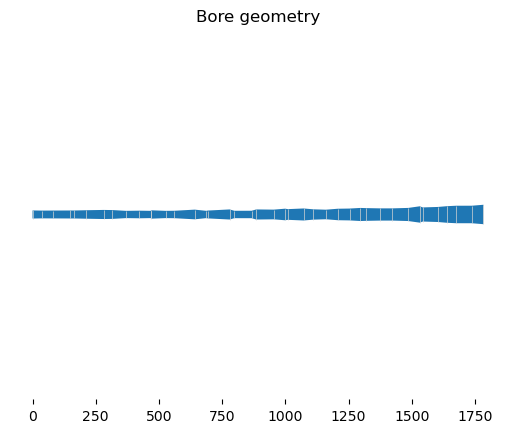

In [27]:
geo.geo

[(0.0, 32.0),
 (52.1063207175451, 18.0),
 (78.92833930955135, 19.665944653450456),
 (115.3858767155674, 18.0),
 (164.95618706564008, 19.953136010860575),
 (224.00058488777307, 20.365333071962752),
 (264.2412538347391, 18.0),
 (302.5305008878063, 26.403689281904377),
 (337.665519431873, 18.0),
 (372.3274364961869, 19.77009963509272),
 (418.150317595346, 24.54058832944464),
 (485.29432208036366, 27.08816245966826),
 (545.5354322716225, 18.0),
 (584.6926562782897, 18.61150745565797),
 (590.958704743461, 24.84522843414601),
 (641.6049833257329, 32.28504554867548),
 (713.5073718043112, 34.85947985442272),
 (728.2108695407983, 22.48153688689315),
 (773.0663738398879, 32.04874430966249),
 (822.3045911694556, 23.241227591770468),
 (894.4405998761481, 37.65769623729425),
 (900.3082978236267, 35.00757593776973),
 (957.5047835933274, 35.579896011738775),
 (999.663193602917, 41.063366963198256),
 (1066.5059032006366, 33.1389452568973),
 (1111.0458896022622, 36.5994327002061),
 (1134.968468391259, 